In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df=pd.read_csv('economic_index.csv')

In [3]:
df.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [4]:
df.drop(columns=['Unnamed: 0','year','month'],axis=1,inplace=True)

In [5]:
df.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [6]:
df.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

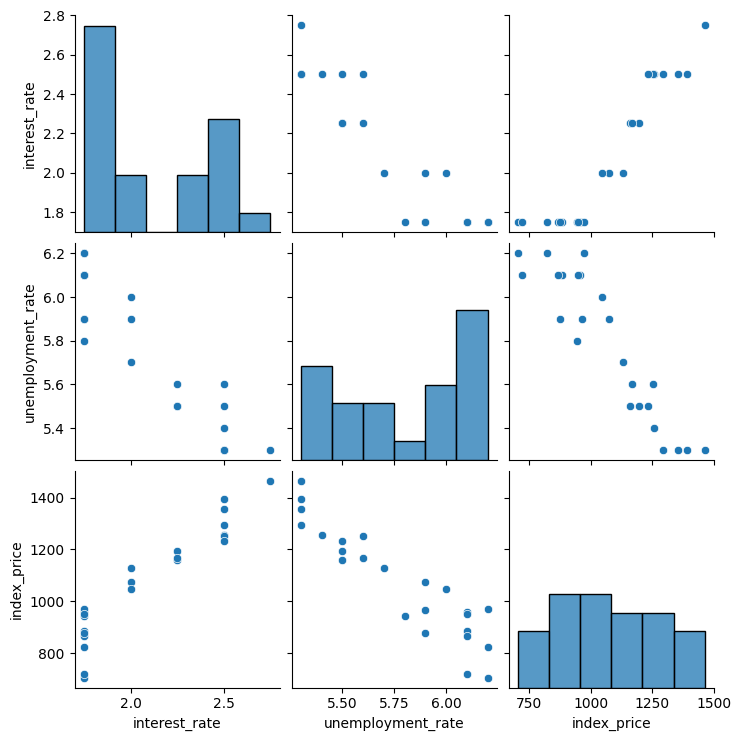

In [7]:
import seaborn as sns
sns.pairplot(df)

In [8]:
df.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


Text(0, 0.5, 'Uneployment Rate')

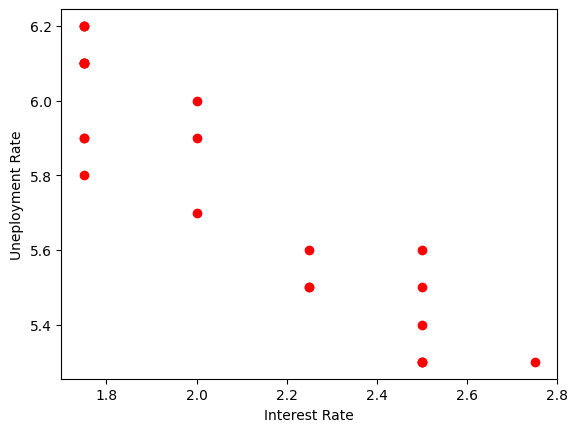

In [9]:
plt.scatter(df['interest_rate'],df['unemployment_rate'],color='r')
plt.xlabel('Interest Rate')
plt.ylabel('Uneployment Rate')

In [10]:
X=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [11]:
X.head(),y.head()

(   interest_rate  unemployment_rate
 0           2.75                5.3
 1           2.50                5.3
 2           2.50                5.3
 3           2.50                5.3
 4           2.50                5.4,
 0    1464
 1    1394
 2    1357
 3    1293
 4    1256
 Name: index_price, dtype: int64)

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

<Axes: xlabel='interest_rate', ylabel='index_price'>

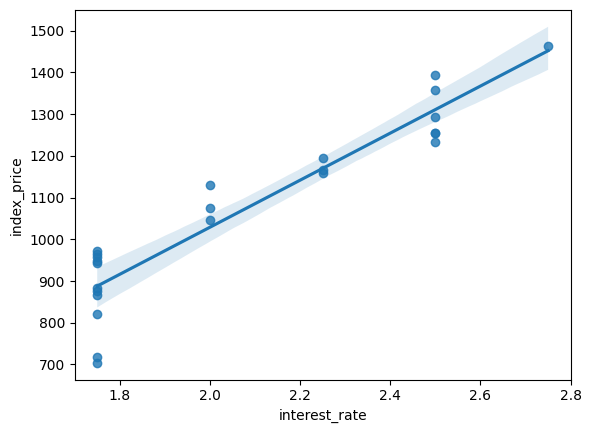

In [13]:
import seaborn as sns
sns.regplot(x=df['interest_rate'],y=df['index_price'])

<Axes: xlabel='interest_rate', ylabel='unemployment_rate'>

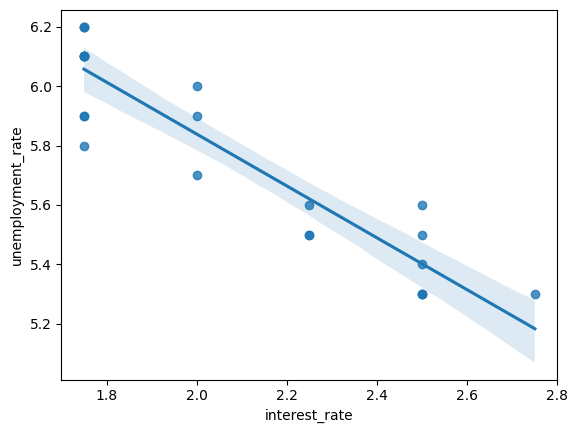

In [14]:
sns.regplot(x=df['interest_rate'],y=df['unemployment_rate'])

<Axes: xlabel='unemployment_rate', ylabel='index_price'>

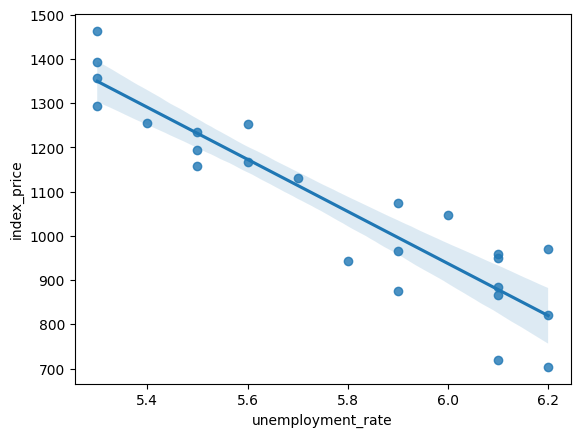

In [15]:
sns.regplot(x=df['unemployment_rate'],y=df['index_price'])

In [16]:
from sklearn.preprocessing import StandardScaler

In [17]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)

In [18]:
X_test

array([[ 0.36115756, -0.82078268],
       [-1.08347268,  1.33377186],
       [ 1.8057878 , -1.43636969],
       [-1.08347268,  1.02597835],
       [-0.36115756,  0.41039134],
       [ 0.36115756, -0.51298918]])

In [19]:
from sklearn.linear_model import LinearRegression
reg=LinearRegression()

In [20]:
reg.fit(X_train,y_train)

LinearRegression()

In [21]:
## Cross Validation
from sklearn.model_selection import cross_val_score
score=cross_val_score(reg,X_train,y_train,scoring='neg_mean_squared_error',
                      cv=3)

In [22]:
np.mean(score)

np.float64(-5914.828180162388)

In [23]:
## prediction
y_pred=reg.predict(X_test)

In [24]:
y_pred

array([1180.7466813 ,  802.74279699, 1379.83457045,  838.52599602,
        973.85313963, 1144.96348227])

In [25]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print('MSE:',mse)
print('MAE:',mae)
print('RMSE:',rmse)

MSE: 8108.567426306604
MAE: 73.80444932337097
RMSE: 90.04758423359621


In [26]:
from sklearn.metrics import r2_score
r_score=r2_score(y_test,y_pred)
print('R^2 Score: ',r_score)
print('Adjusted R^2 Score: ',(1-(1-r_score)*(len(y_test)-1)/(len(y_test)-
                                X_test.shape[1]-1)))


R^2 Score:  0.7591371539010257
Adjusted R^2 Score:  0.5985619231683761


## Assumptions:

<Axes: xlabel='index_price'>

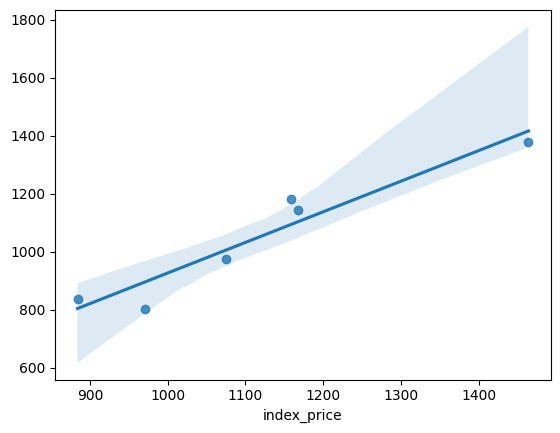

In [27]:
sns.regplot(x=y_test,y=y_pred)

In [29]:
res=y_test-y_pred
res

8     -21.746681
16    168.257203
0      84.165430
18     45.474004
11    101.146860
9      22.036518
Name: index_price, dtype: float64

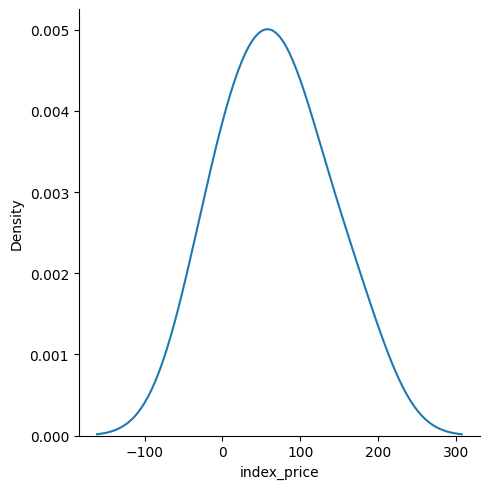

In [31]:
sns.displot(res,kind='kde')

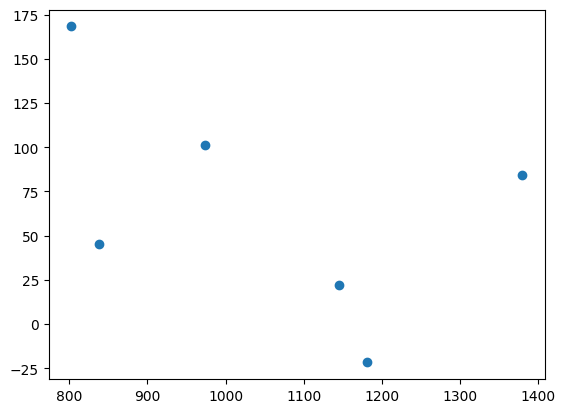

In [32]:
## Uniformity in scatter plot
plt.scatter(y_pred,res)

In [33]:
import statsmodels.api as sm

In [34]:
model=sm.OLS(y_train,X_train).fit()

In [36]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Sun, 05 Oct 2025   Prob (F-statistic):                       0.754
Time:                        08:08:44   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

e:\ML Bootcamp Krish Naik\Code\venv\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [39]:
reg.coef_

array([  88.27275507, -116.25716066])

In [40]:
reg.intercept_

np.float64(1053.4444444444443)